In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.integrate import odeint
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler
import scipy.stats as stats
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import LeaveOneOut
import seaborn as sns
import pyEDM

,time,Aphanizomenon_flos-aquae,Planktothrix_rubescens,Phacotus_lenticularis,Pandorina_morum,Elakatothrix_gelatinosa,Closterium_aciculare,Cosmarium_sp,Staurastrum_sp,Stephanodiscus_sp,...,Diaptomus_sp_C4-C5,Eudiaptomus_gracilis_male,Eudiaptomus_gracilis_ovaria,Eudiaptomus_gracilis_female,Cyclops_abyssorum_male,Cyclops_sp_SU_C1-C3,Cyclops_sp_SU_C4-C5,Cyclopoida_nauplia,Cyclops_abyssorum_female,Cyclops_sp_eggs
0,1,0.026471,0.098771,0.055546,0.000000,0.000000,0.295599,0.182574,0.181969,0.000000,...,0.726634,0.692425,0.000000,0.382562,0.546201,0.519346,0.700245,0.519360,0.165439,0.477767
1,2,0.024028,0.089810,0.028283,0.000000,0.000000,0.197066,0.000000,0.081379,0.051647,...,0.233966,0.140666,0.000000,0.000000,0.191281,0.177544,0.311009,0.261267,0.067111,0.118872
2,3,0.023532,0.087324,0.021380,0.081923,0.057221,0.241355,0.000000,0.162758,0.135557,...,0.421171,0.424694,0.000000,0.270512,0.471534,0.190124,0.477480,0.428488,0.082194,0.414414
3,4,0.039616,0.217751,0.030235,0.115857,0.054181,0.098533,0.000000,0.181969,0.086079,...,0.594024,0.316348,0.598477,0.304759,0.526524,0.638668,1.000000,0.449387,0.168807,0.378067
4,5,0.124877,0.038317,0.000000,0.306529,0.043811,0.000000,0.341565,0.244137,0.076991,...,0.977686,1.000000,0.000000,0.000000,0.607205,0.633898,0.388037,0.762868,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,361,0.051306,0.498205,0.254768,0.271708,0.033601,0.170664,0.365148,0.115087,0.070704,...,0.080996,0.086703,0.143499,0.164959,0.362441,0.108029,0.133924,0.219601,0.055736,0.093573
361,362,0.032440,0.456663,0.137729,0.259064,0.028113,0.139347,0.288675,0.081379,0.015074,...,0.111784,0.091868,0.133723,0.184064,0.282058,0.157128,0.088789,0.158795,0.061396,0.122012
362,363,0.048166,0.631754,0.088796,0.295378,0.026027,0.000000,0.223607,0.000000,0.033707,...,0.107096,0.132943,0.163669,0.234309,0.314961,0.159494,0.143716,0.161820,0.075456,0.106865
363,364,0.048708,0.707757,0.095013,0.245770,0.028113,0.000000,0.182574,0.081379,0.060296,...,0.082291,0.087578,0.166175,0.191909,0.306796,0.075372,0.114834,0.106624,0.068378,0.118428


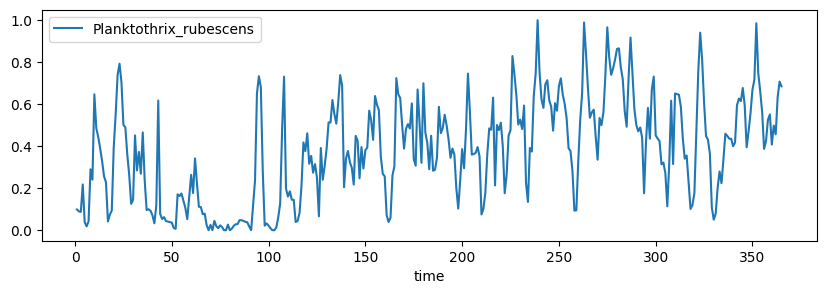

In [2]:
# Example data: monthly Lake Zurich plankton time series
data = pd.read_csv('LakeZurichData_example.csv', index_col=0)
display(data)
# data['time'] = data.index+1

sp = 'Planktothrix_rubescens'
data.plot(x='time', y=sp, figsize=(10,3))
plt.show()

## kNN Approach
* Almost always uses τ = -1
* Usually uses uniform weighting of k nearest neighbors (not exponential distance weighting like Simplex)
* Optimizes both E and k (does not fix k = E + 1 like Simplex)

In [3]:
# kNN approach

def optimized_knn_E_vs_rho(dataFrame, var, E_range, tau, Tp, k_range, exclusion_radius=0):
    '''Optimized grid search for E and k using vectorized pairwise distances.
       Returns: (DataFrame of parameter search results, DataFrame of best predictions)'''
    results = []
    best_overall_runs = {}
    for E in E_range:
        # 1. Compute embedding ONCE per E
        embedding = pyEDM.Embed(dataFrame=dataFrame, columns=var, E=E, tau=tau)
        columns = embedding.columns.tolist()
        target = columns[0]
        
        X_all = embedding.loc[:, columns].values
        y_all = embedding[[target]].shift(-Tp).values.flatten()

        # Filter out NaN rows
        valid_mask = ~np.isnan(X_all).any(axis=1) & ~np.isnan(y_all)
        X_clean = X_all[valid_mask]
        y_clean = y_all[valid_mask]
        n_samples = len(X_clean)

        valid_indices = embedding.index[valid_mask]

        # 2. Precompute ALL pairwise distances once for this E. 
        # dist_matrix[i,j] is the distance between point i and point j
        dist_matrix = cdist(X_clean, X_clean, metric='euclidean')

        # 3. Apply exclusion radius by setting excluded distances to infinity
        if exclusion_radius >= 0:
            # Create a matrix of index differences |i - j|
            idx_diff = np.abs(np.arange(n_samples)[:, None] - np.arange(n_samples))
            exclude_mask = idx_diff <= exclusion_radius
            dist_matrix[exclude_mask] = np.inf

        # Sort neighbors by distance once per E (get indices of nearest neighbors)
        # Each row i contains the indices of points sorted by closeness to i
        nearest_neighbor_indices = np.argsort(dist_matrix, axis=1)
        
        best_rho = -np.inf
        best_k = None
        best_preds_for_this_E = None

        # 4. Fast loop over k_range
        for k in k_range:
            if k > n_samples:
                continue
                
            # Get the top k neighbor indices for all points simultaneously
            k_neighbors = nearest_neighbor_indices[:, :k]
            
            # Retrieve the y-values of neighbors and average them
            predictions = np.mean(y_clean[k_neighbors], axis=1)
            
            # Calculate correlation coefficient
            rho = np.corrcoef(y_clean, predictions)[0, 1]
            
            if rho > best_rho:
                best_rho = rho
                best_k = k
                best_preds_for_this_E = predictions
                
        results.append({'E': E, 'best_k': best_k, 'best_rho': best_rho})

        # Save the best metadata and predictions for this specific E loop
        best_overall_runs[E] = {
            'k': best_k, 
            'rho': best_rho, 
            'actual': y_clean, 
            'predicted': best_preds_for_this_E,
            'index': valid_indices
        }

    results_df = pd.DataFrame(results)
    
    # 5. Find the absolute best E across the entire grid search
    best_row = results_df.sort_values(by='best_rho', ascending=False).iloc[0]
    best_E_overall = int(best_row['E'])
    
    # Extract the pre-calculated actuals and predictions for that absolute best configuration
    best_run_data = best_overall_runs[best_E_overall]
    
    predictions_df = pd.DataFrame({
        'Actual': best_run_data['actual'],
        'Predicted': best_run_data['predicted']
    }, index=best_run_data['index'])
        
    return results_df, predictions_df

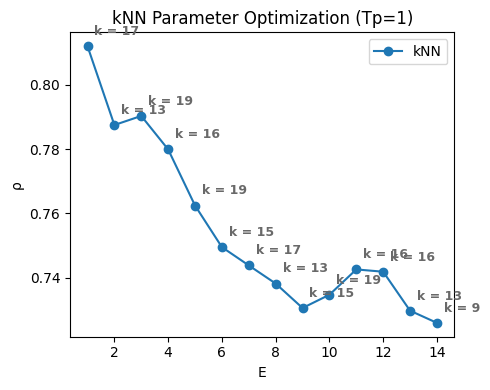

Best parameters:


,E,best_k,best_rho
0,1,17,0.812008


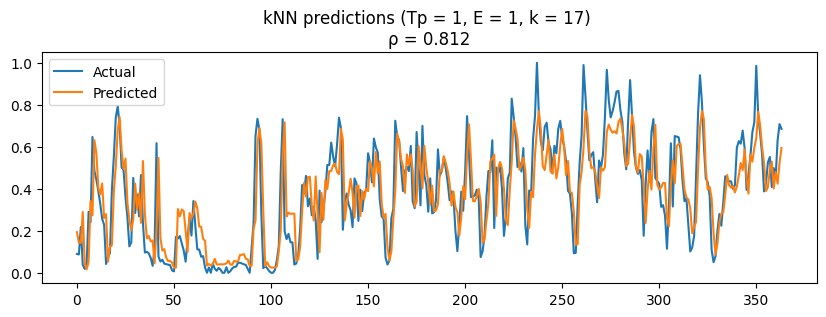

In [4]:
# Optimize kNN parameters
E_range = range(1, 15)
k_range = range(2, 20)
tau = -1
Tp = 1

knn_results, predictions = optimized_knn_E_vs_rho(data, sp, E_range, tau, Tp, k_range, exclusion_radius=12)

# --- Plot parameter optimization ---
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(knn_results['E'], knn_results['best_rho'], marker='o', color='tab:blue', label='kNN')
for idx, row in knn_results.iterrows():
    ax.annotate(f'k = {int(row["best_k"])}',(row['E'], row['best_rho']), textcoords="offset points", 
        xytext=(5, 8), ha='left', fontsize=9, fontweight='bold',color='dimgray')
ax.set_xlabel('E')
ax.set_ylabel('ρ')
ax.set_title(f'kNN Parameter Optimization (Tp={Tp})')
ax.legend()
plt.tight_layout()
plt.show()

# Display best E/k pair
print('Best parameters:')
best = knn_results.sort_values(by='best_rho', ascending=False).head(1).reset_index(drop=True)
display(best)

best_E = best.loc[0,'E']
best_k = best.loc[0,'best_k']

knn_results, predictions = optimized_knn_E_vs_rho(data, sp, [best_E], tau, Tp, [best_k], exclusion_radius=12)

# --- Plot observed vs. predicted values ---
fig, ax = plt.subplots(figsize=(10,3))
predictions.plot(y=['Actual', 'Predicted'], ax=ax)
ax.set_title(f'kNN predictions (Tp = {Tp}, E = {knn_results.loc[0,'E']}, k = {knn_results.loc[0,'best_k']}) \nρ = {knn_results.loc[0,'best_rho']:.3f}')
plt.show()

kNN says E=1, k=17, Tp=1 gives the best predictability. But what have we learned about the dynamics?

## Simplex approach
The goal of Simplex is not necessarily just to make the best predictions. It's a minimal approach to finding the dimensionality and timescale of the underlying dynamics.
* Find the (E,τ) pair that best unfolds the attractor
* Fix E = k + 1 (minimal number of neighbors needed to form a simplex in the E-dimensional space)
* Must outperform the constant predictor

In [5]:
## Using suggested Simplex wrapper function
def simplex_wrapper(
    dataFrame=None,
    columns='',
    target='',
    lib='',
    pred='',
    E=0,
    Tp=1,
    knn=0,
    tau=-1,
    exclusionRadius=0,
    embedded=False,
    validLib=None,
    noTime=False,
    generateSteps=0,
    generateConcat=False,
    verbose=False,
    showPlot=None,
    ignoreNan=True,        
    handleNan=False,        # automatically handles missing values if True (so you don't have to manually use validLib)
    returnObject=False,
    metric='rho',
    sig=0.05,
    figsize=(10,3.5),
    decimals=None,
    plot_kwargs=None,       # Extra kwargs passed to ax.plot(), e.g. {'linestyle': '.', 'color': 'red'}
):
    """Wrapper for pyEDM Simplex function.

    E and tau can be given as integers (in which case it simply returns
    the Simplex output), or as a list (in which case it returns a table
    of E/tau prediction skill and their significance against the constant
    predictor).

    Args:
        dataFrame: Input DataFrame.
        columns: Predictor column name(s).
        target: Target column name.
        lib: Library indices string, e.g. '1 100'.
        pred: Prediction indices string, e.g. '1 100'.
        E: Embedding dimension — int or list of ints.
        Tp: Prediction horizon.
        knn: Number of nearest neighbours (0 = E+1).
        tau: Embedding lag — int or list of ints.
        exclusionRadius: Temporal exclusion radius.
        embedded: Whether dataFrame is already embedded.
        validLib: Boolean vector marking valid library rows.
        noTime: If True, treat first column as data, not time.
        generateSteps: Number of generative steps.
        generateConcat: If True, concatenate generative output.
        verbose: Print progress information.
        showPlot: Plot results.
        ignoreNan: Ignore NaN values.
        returnObject: Return the full Simplex object.
        metric: Skill metric for E/tau comparison (default 'rho').
        sig: Significance level for hypothesis tests (default 0.01).
        figsize: Figure size for plots; None uses the default.
        decimals: Decimal places in output table; None uses the default.

    Returns:
        dict: When E and tau are both integers:
                {'Predictions': <simplex output>,
                 'Summary Statistics': <statistics>}
              When either is a list: the output of E_vs_tau().
    """

    # Default behavior
    if validLib is None:
        validLib = []
    if plot_kwargs is None:
        plot_kwargs = {'style': '.-'}

    # showPlot default is True if E/tau are lists; False if E/tau are integers
    if showPlot is None:
        showPlot = not (isinstance(E, int) and isinstance(tau, int))

    # Use entire time series as lib/pred if none are specified
    if lib == '':
        lib = f'1 {len(dataFrame)}'
    if pred == '':
        pred = f'1 {len(dataFrame)}'

    # If E and tau are both integers: return Simplex output + summary stats
    if isinstance(E, int) and isinstance(tau, int):

        # Optional: add automatic handling of missing values using validLib
        # validLib = True where embedding vectors and target(t+Tp) are not NaN
        if handleNan == True:
            if embedded == False:
                embedding = pyEDM.Embed(dataFrame=dataFrame, E=E, tau=tau, columns=columns)
            else:
                embedding = dataFrame[columns]
            valid_embed = embedding.notna().all(axis=1)
            valid_target = dataFrame[target].shift(-Tp).notna()
            validLib = valid_embed & valid_target

        # Run pyEDM Simplex function
        out = pyEDM.Simplex(
            dataFrame=dataFrame,
            columns=columns,
            target=target,
            lib=lib,
            pred=pred,
            E=E,
            Tp=Tp,
            knn=knn,
            tau=tau,
            exclusionRadius=exclusionRadius,
            embedded=embedded,
            validLib=validLib,
            noTime=noTime,
            generateSteps=generateSteps,
            generateConcat=generateConcat,
            verbose=verbose,
            showPlot=False,                  # Suppress pyEDM's native plot
            ignoreNan=ignoreNan,
            returnObject=returnObject,
        )

        # Returns Simplex object if returnObject = True; does not calculate summary statistics or make plot
        if returnObject == True:
            return out
        
        statistics = calculate_summary_statistics(out, columns, target, Tp)

        # Improved default plot
        if showPlot:
            if decimals is None:
                decimals = 3
            rho = statistics.loc['rho', 'Simplex']
            fig, ax = plt.subplots(figsize=figsize)
            out.plot(ax=ax, x='Time', y=['Observations', 'Predictions'], **plot_kwargs)
            ax.set_xlabel('Time')
            ax.set_ylabel(target)
            ax.set_title(f'Simplex Predictions for {target} (Tp={Tp}, E={E}, τ={tau}) \nρ = {rho:.{decimals}f}')
            ax.legend()
            plt.tight_layout()
            plt.show()
                    
        output = {'Predictions': out, 'Summary Statistics': statistics}

    # If E or tau is a list: run E_vs_tau grid search
    else:
        if isinstance(E, int) and isinstance(tau, list):
            E = [E]
        elif isinstance(E, list) and isinstance(tau, int):
            tau = [tau]
        # If both are already lists, no conversion is needed
        output = E_vs_tau(
            dataFrame=dataFrame,
            columns=columns,
            target=target,
            lib=lib,
            pred=pred,
            E=E,
            Tp=Tp,
            knn=knn,
            tau=tau,
            exclusionRadius=exclusionRadius,
            embedded=embedded,
            validLib=validLib,
            noTime=noTime,
            generateSteps=generateSteps,
            generateConcat=generateConcat,
            verbose=verbose,
            showPlot=showPlot,
            ignoreNan=ignoreNan,
            returnObject=returnObject,
            metric=metric,
            sig=sig,
            figsize=figsize,
            decimals=decimals,
        )

    return output

def fisher_z_test(rho_1, rho_2, n_1, n_2, sig):
    """Test if rho_1 is significantly larger than rho_2 using Fisher's z-transformation."""

    rho_1 = np.clip(rho_1, -0.9999, 0.9999)
    rho_2 = np.clip(rho_2, -0.9999, 0.9999)
    
    z_1 = 0.5 * np.log((1 + rho_1) / (1 - rho_1))
    z_2 = 0.5 * np.log((1 + rho_2) / (1 - rho_2))

    se = np.sqrt((1 / (n_1 - 3)) + (1 / (n_2 - 3)))
    z = (z_1 - z_2) / se
    p_value = 1 - stats.norm.cdf(z)

    return int(p_value < sig)


def one_tailed_t_test(list_1, list_2, sig):
    """Test if the mean of list_1 is significantly larger than the mean of list_2 using a one-tailed t-test."""
    
    u_1, u_2 = np.mean(list_1), np.mean(list_2)
    sd_1, sd_2 = np.std(list_1), np.std(list_2)
    n_1, n_2 = len(list_1), len(list_2)

    se = np.sqrt((sd_1**2 / n_1) + (sd_2**2 / n_2))
    t = (u_2 - u_1) / se

    numerator = ((sd_1**2 / n_1) + (sd_2**2 / n_2)) ** 2
    denominator = ((sd_1**2 / n_1) ** 2 / (n_1 - 1)) + ((sd_2**2 / n_2) ** 2 / (n_2 - 1))
    dof = numerator / denominator

    p_value = stats.t.cdf(t, dof)

    return int(p_value < sig)


def calculate_summary_statistics(results, columns, target, Tp):
    """Calculate summary statistics for Simplex and constant predictor."""
    summary_statistics = pd.DataFrame(
        None,
        index=['rho', 'MAE', 'RMSE', '% Correct Sign', 'N Predicted'],
        columns=['Simplex', 'Constant Predictor'],
    )

    df = results.copy()
    df['Constant Predictor'] = df['Observations'].shift(Tp)

    # Correlation
    summary_statistics.loc['rho', 'Simplex'] = df.corr().loc['Observations', 'Predictions']
    summary_statistics.loc['rho', 'Constant Predictor'] = df.corr().loc['Observations', 'Constant Predictor']

    # MAE
    summary_statistics.loc['MAE', 'Simplex'] = np.abs(df['Observations'] - df['Predictions']).mean()
    summary_statistics.loc['MAE', 'Constant Predictor'] = np.abs(df['Observations'] - df['Constant Predictor']).mean()

    # RMSE
    summary_statistics.loc['RMSE', 'Simplex'] = np.sqrt(((df['Observations'] - df['Predictions']) ** 2).mean())
    summary_statistics.loc['RMSE', 'Constant Predictor'] = np.sqrt(((df['Observations'] - df['Constant Predictor']) ** 2).mean())

    # % Correct Sign
    df['ObsSign'] = np.sign(df['Observations'].diff())
    df['PredSign_Simplex'] = np.sign(df['Predictions'].diff())
    df['PredSign_Constant_Predictor'] = np.sign(df['Constant Predictor'].diff())

    valid = ~df['ObsSign'].isnull()
    correct_simplex = ((df['ObsSign'] == df['PredSign_Simplex']) & valid).sum()
    correct_const = ((df['ObsSign'] == df['PredSign_Constant_Predictor']) & valid).sum()
    total_predictions = valid.sum()

    summary_statistics.loc['% Correct Sign', 'Simplex'] = (correct_simplex / total_predictions) * 100
    summary_statistics.loc['% Correct Sign', 'Constant Predictor'] = (correct_const / total_predictions) * 100

    # N Predicted (number of Observed/Predicted pairs)
    summary_statistics.loc['N Predicted', 'Simplex'] = len(df[['Observations', 'Predictions']].dropna())
    summary_statistics.loc['N Predicted', 'Constant Predictor'] = len(df[['Observations', 'Constant Predictor']].dropna())

    # If cross-mapping, do not return constant predictor values
    is_cross_mapping = target not in columns
    if is_cross_mapping:
        summary_statistics.loc[:,'Constant Predictor'] = np.nan

    return summary_statistics


def E_vs_tau(
    dataFrame=None,
    columns='',
    target='',
    lib='',
    pred='',
    E=0,
    Tp=1,
    knn=0,
    tau=-1,
    exclusionRadius=0,
    embedded=False,
    validLib=None,
    noTime=False,
    generateSteps=0,
    generateConcat=False,
    verbose=False,
    showPlot=False,
    ignoreNan=True,
    returnObject=False,
    metric='rho',
    sig=0.01,
    figsize=None,
    decimals=None,
):
    """Compute Simplex prediction skill across a grid of E and tau values.

    Args:
        dataFrame: Input DataFrame.
        columns: Predictor column name(s).
        target: Target column name.
        lib: Library indices string.
        pred: Prediction indices string.
        E: List of embedding dimensions to test.
        Tp: Prediction horizon.
        knn: Number of nearest neighbours (0 = E+1).
        tau: List of embedding lags to test.
        exclusionRadius: Temporal exclusion radius.
        embedded: Whether dataFrame is already embedded.
        validLib: Boolean vector marking valid library rows.
        noTime: If True, treat first column as data, not time.
        generateSteps: Number of generative steps.
        generateConcat: If True, concatenate generative output.
        verbose: Print progress information.
        showPlot: Plot results (unused internally; plot always shown).
        ignoreNan: Ignore NaN values.
        returnObject: Return the full Simplex object.
        metric: Skill metric — 'rho' or 'MAE' (default 'rho').
        sig: Significance level for hypothesis tests (default 0.01).
        figsize: Matplotlib figure size tuple; None uses the default.
        decimals: Decimal places in heatmap annotations; None defaults to 4.

    Returns:
        dict: {
            'E_vs_tau': DataFrame of metric values,
            'significance': DataFrame of significance flags (1 = significant)
        }
    """
    if validLib is None:
        validLib = []

    # Determine if we are cross-mapping (determines whether we compare with the constant predictor)
    is_cross_mapping = target not in columns
    
    E_tau = pd.DataFrame(index=tau, columns=E)
    E_tau_sig = pd.DataFrame(index=tau, columns=E)

    for _E_ in E:
        for _tau_ in tau:
            s = simplex_wrapper(
                dataFrame=dataFrame,
                columns=columns,
                target=target,
                lib=lib,
                pred=pred,
                E=_E_,
                Tp=Tp,
                knn=knn,
                tau=_tau_,
                exclusionRadius=exclusionRadius,
                embedded=embedded,
                validLib=validLib,
                noTime=noTime,
                generateSteps=generateSteps,
                generateConcat=generateConcat,
                verbose=verbose,
                showPlot=False,
                ignoreNan=ignoreNan,
                returnObject=returnObject,
            )
            simplex_metric = s['Summary Statistics']['Simplex'][metric]
            n_simplex = s['Summary Statistics']['Simplex']['N Predicted']
            const_metric = s['Summary Statistics']['Constant Predictor'][metric]
            n_const = s['Summary Statistics']['Constant Predictor']['N Predicted']

            if is_cross_mapping:     # No equivalent to constant predictor for cross-mapping
                significant = None
            elif metric == 'rho':
                significant = fisher_z_test(simplex_metric, const_metric, n_simplex, n_const, sig)
            elif metric == 'MAE':
                abs_error_simplex = np.abs(
                    s['Predictions']['Observations'] - s['Predictions']['Predictions']
                )
                abs_error_const_df = s['Predictions'].copy()
                abs_error_const_df['Constant Predictor'] = abs_error_const_df['Observations'].shift(Tp)
                abs_error_const = np.abs(
                    abs_error_const_df['Observations'] - abs_error_const_df['Constant Predictor']
                )
                significant = one_tailed_t_test(abs_error_const, abs_error_simplex, sig)
            else:
                raise NotImplementedError(f"Significance test not implemented for metric '{metric}'.")

            E_tau.at[_tau_, _E_] = simplex_metric
            E_tau_sig.at[_tau_, _E_] = significant

    E_tau = E_tau.apply(pd.to_numeric, errors='coerce')
    E_tau_sig = E_tau_sig.apply(pd.to_numeric, errors='coerce')

    # Plot
    if showPlot == True:
        cmap = 'viridis' if metric == 'rho' else 'viridis_r'
        metric_title = 'ρ' if metric == 'rho' else 'MAE'
        decimals = decimals if decimals is not None else 4
    
        fig = plt.figure(figsize=figsize)  # figsize=None uses matplotlib default
    
        has_sig_points = np.any(E_tau_sig == 1)
        if has_sig_points:
            vmin = np.nanmin(E_tau[E_tau_sig == 1])
            vmax = np.nanmax(E_tau[E_tau_sig == 1])
        else:
            vmin = np.nanmin(E_tau.values)
            vmax = np.nanmax(E_tau.values)
    
        sns.heatmap(
            E_tau,
            annot=True,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            fmt=f'.{decimals}f',
            cbar_kws={'label': metric_title},
        )
        all_nan_sig = np.all(np.isnan(E_tau_sig.values.astype(float)))
        all_significant = np.all(E_tau_sig == 1)
        if not all_significant and not all_nan_sig:
            sns.heatmap(
                E_tau_sig,
                mask=E_tau_sig,
                cbar=False,
                annot=False,
                cmap=sns.color_palette(['darkgray']),
            )
        plt.title(f'{metric_title} Values for Es and taus (Tp = {Tp}, metric = {metric})')
        plt.xlabel('E')
        plt.ylabel('tau')
        plt.show()

    return {'E_vs_tau': E_tau, 'significance': E_tau_sig}

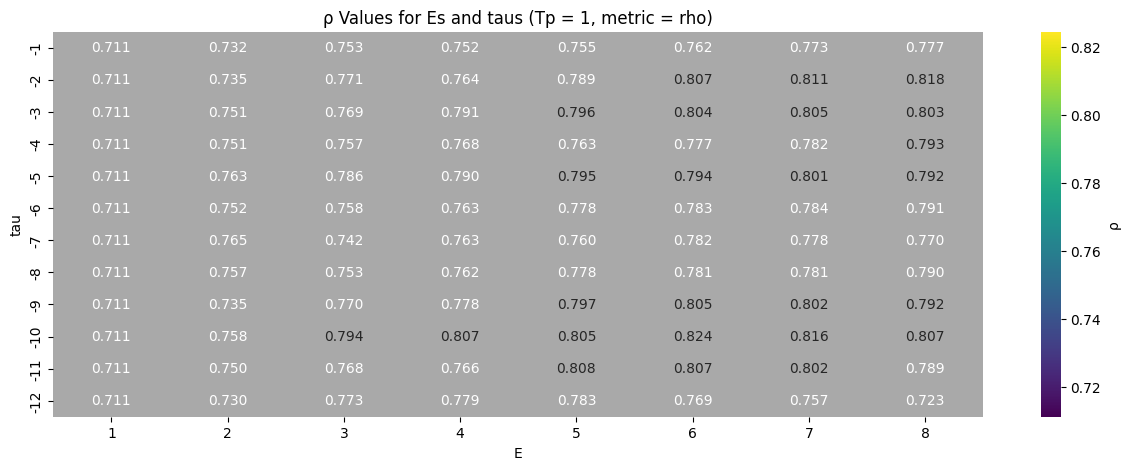

In [6]:
E = list(range(1,9))
tau = list(reversed(range(-12,0)))
Tp = 1
simplex = simplex_wrapper(dataFrame=data, columns=sp, target=sp, E=E, Tp=Tp, tau=tau, 
                          sig=0.05, metric='rho', figsize=(15,5), decimals=3)

Here, we see that at a timescale of Tp = 1 months, any attractor dynamics are not significantly more informative than the constant predictor. The dynamics are dominated by autocorrelation at this timescale. Tp represents the timescale in the difference equation

$$X(t+Tp) = F(X(t))$$

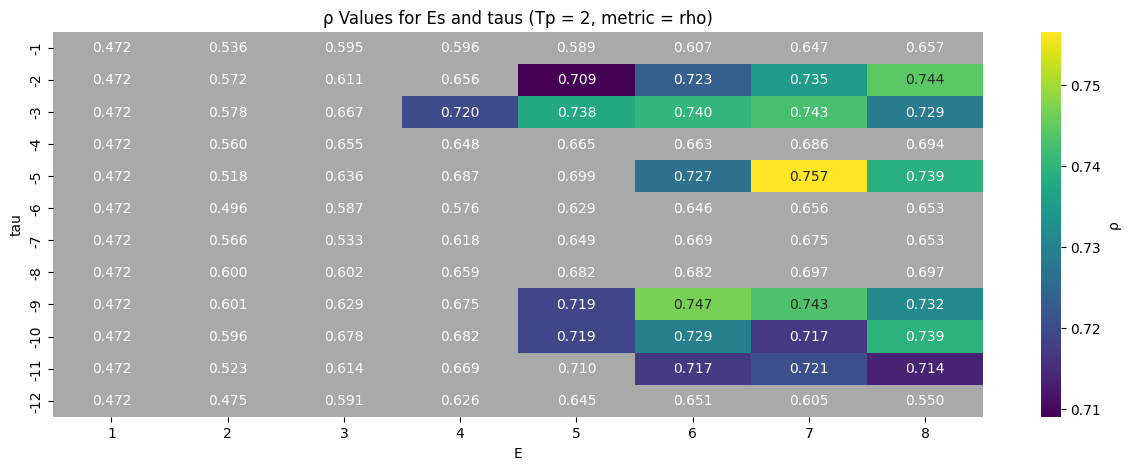

In [7]:
# Trying Tp = 2
Tp = 2
simplex = simplex_wrapper(dataFrame=data, columns=sp, target=sp, E=E, Tp=Tp, tau=tau, 
                          sig=0.05, metric='rho', figsize=(15,5), decimals=3)

Here, we see that the minimal (E, tau) pair that represents the Tp = 2 dynamics significantly better than the constant predictor is E = 4, tau = -3. 

If we want to learn about the nonlinear dynamics of this species, we should be looking at a timescale of Tp = 2 months, and use a model with dimension E = 4 and time lag tau = -3. (even if this does not give the best predictions)

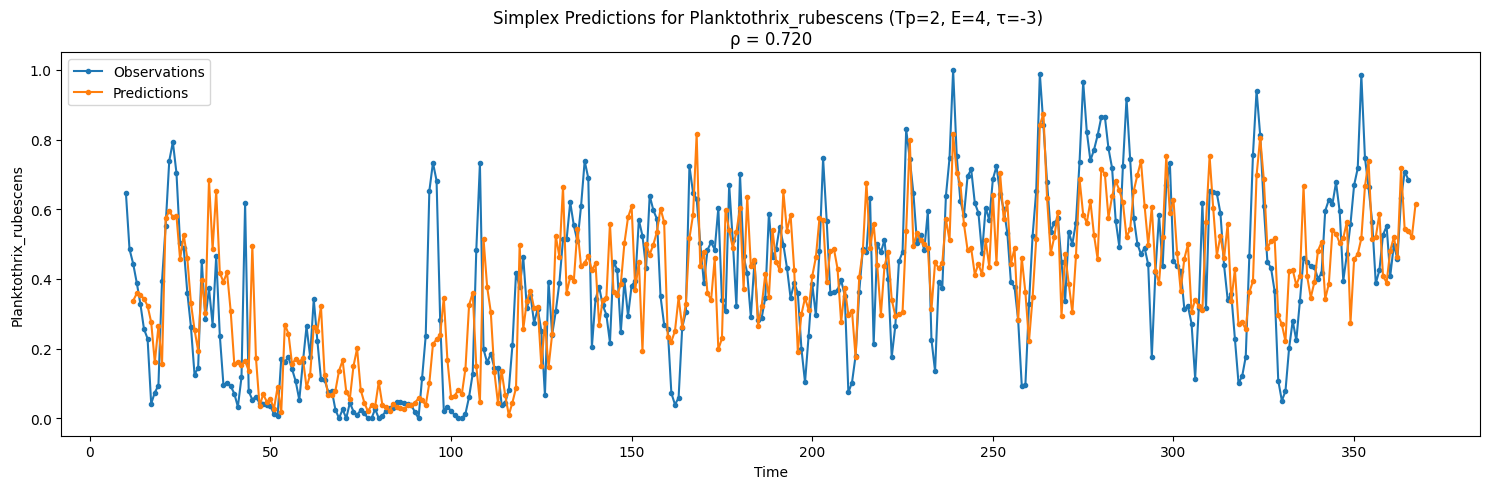

In [8]:
E = 4
tau = -3
Tp = 2
simplex = simplex_wrapper(dataFrame=data, columns=sp, target=sp, E=E, Tp=Tp, tau=tau, 
                          sig=0.05, metric='rho', figsize=(15,5), decimals=3, showPlot=True)

As we continue to increase Tp, Simplex outperforms kNN. 

### Tp = 3

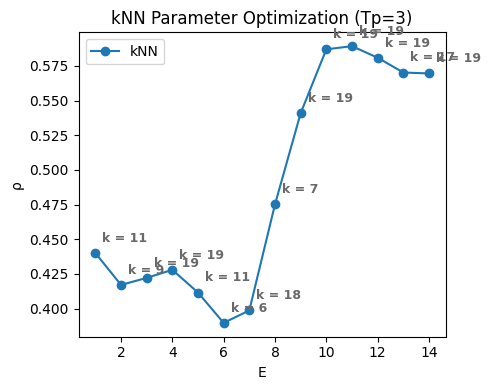

Best parameters:


,E,best_k,best_rho
0,11,19,0.589235


Text(0.5, 1.0, 'kNN predictions (Tp = 3, E = 11, k = 19) \nρ = 0.589')

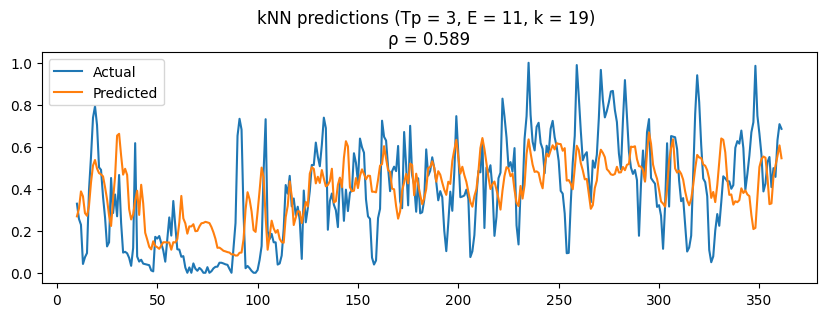

In [9]:
# Optimize kNN parameters
E_range = range(1, 15)
k_range = range(2, 20)
tau = -1
Tp = 3

knn_results, predictions = optimized_knn_E_vs_rho(data, sp, E_range, tau, Tp, k_range, exclusion_radius=12)

# --- Plot parameter optimization ---
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(knn_results['E'], knn_results['best_rho'], marker='o', color='tab:blue', label='kNN')
for idx, row in knn_results.iterrows():
    ax.annotate(f'k = {int(row["best_k"])}',(row['E'], row['best_rho']), textcoords="offset points", 
        xytext=(5, 8), ha='left', fontsize=9, fontweight='bold',color='dimgray')
ax.set_xlabel('E')
ax.set_ylabel('ρ')
ax.set_title(f'kNN Parameter Optimization (Tp={Tp})')
ax.legend()
plt.tight_layout()
plt.show()

# Display best E/k pair
print('Best parameters:')
best = knn_results.sort_values(by='best_rho', ascending=False).head(1).reset_index(drop=True)
display(best)

best_E = best.loc[0,'E']
best_k = best.loc[0,'best_k']

knn_results, predictions = optimized_knn_E_vs_rho(data, sp, [best_E], tau, Tp, [best_k], exclusion_radius=12)

# --- Plot observed vs. predicted values ---
fig, ax = plt.subplots(figsize=(10,3))
predictions.plot(y=['Actual', 'Predicted'], ax=ax)
ax.set_title(f'kNN predictions (Tp = {Tp}, E = {knn_results.loc[0,'E']}, k = {knn_results.loc[0,'best_k']}) \nρ = {knn_results.loc[0,'best_rho']:.3f}')
#plt.show()

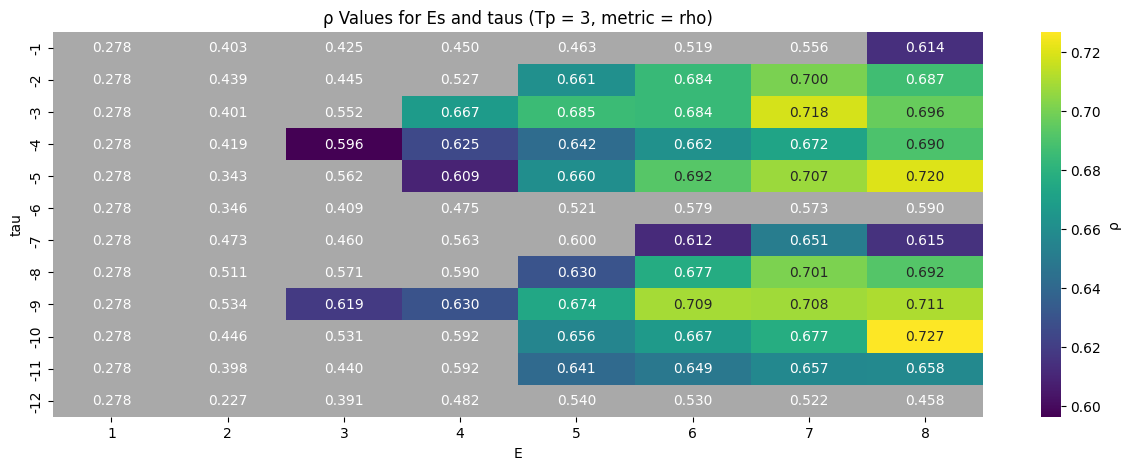

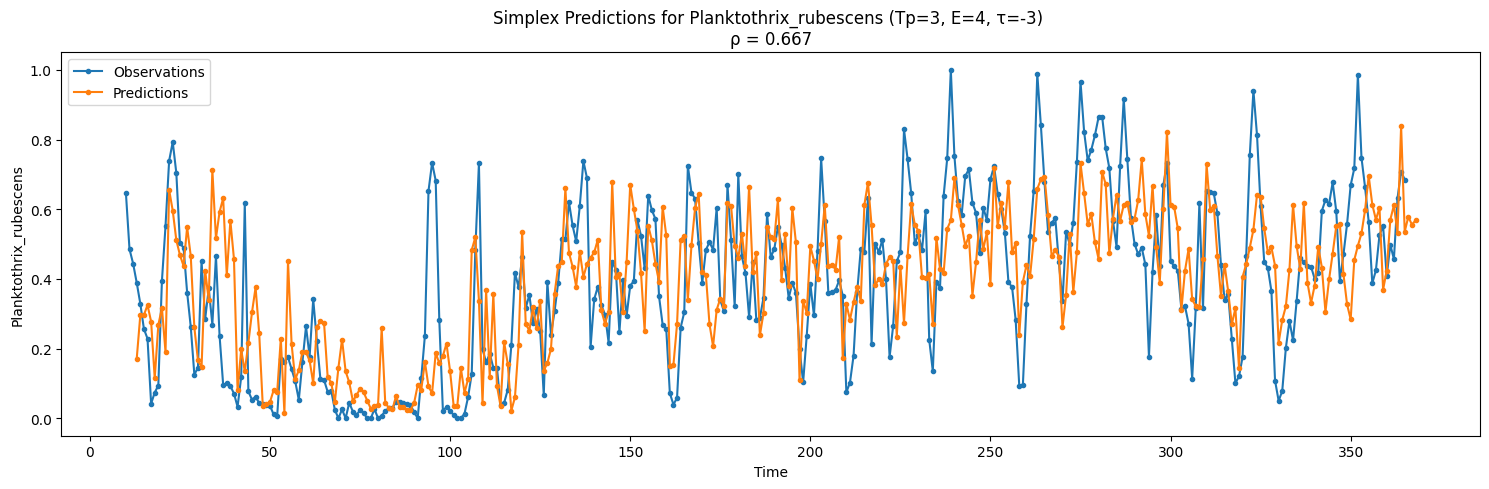

In [10]:
# Simplex
E = list(range(1,9))
tau = list(reversed(range(-12,0)))
Tp = 3
simplex = simplex_wrapper(dataFrame=data, columns=sp, target=sp, E=E, Tp=Tp, tau=tau, 
                          sig=0.05, metric='rho', figsize=(15,5), decimals=3)

# Choosing parameters based on E/tau grid search
E = 4
tau = -3
simplex = simplex_wrapper(dataFrame=data, columns=sp, target=sp, E=E, Tp=Tp, tau=tau, 
                          sig=0.05, metric='rho', figsize=(15,5), decimals=3, showPlot=True)

The same pattern continues for higher Tp values.  

At short prediction horizons (Tp=1), prediction skill is largely based on autocorrelation. kNN excels here because tuning a larger k allows it to smooth out noise.

However, at longer horizons (Tp>1), the underlying nonlinear dynamics cause nearby states to diverge. kNN's uniform averaging does not capture this well. Simplex outperforms kNN at higher Tp because its fixed, minimal number of neighbors (k=E+1) and exponential distance weighting capture the local structure better.  

kNN regression also does not typically optimize tau (it always uses tau = -1). This means that the "attractor" it reconstructs (in our terms) is not going to be unfolded well in the state space if the time series is autocorrelated, and there will be many singularities.

## Second Example: Lorenz System

In [11]:
# 1. Generate Lorenz Data
def lorenz(state, t, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

sigma, rho, beta = 10, 28, 8/3
initial_state = [1.0, 1.0, 1.0]
dt = 0.01  # Smaller dt for better integration accuracy
total_time = 200  # Increased to allow for burn-in
burn_in_time = 20  # Time to discard

# 2. Generate Data
t = np.arange(0, total_time, dt)
data_raw = odeint(lorenz, initial_state, t, args=(sigma, rho, beta))

# 3. Create DataFrame and Apply Burn-in
# We discard the first (burn_in_time / dt) steps
burn_in_steps = int(burn_in_time / dt)
df = pd.DataFrame({
    'time': t[burn_in_steps:], 
    'x': data_raw[burn_in_steps:, 0],
    'y': data_raw[burn_in_steps:, 1],
    'z': data_raw[burn_in_steps:, 2]
}).reset_index(drop=True)

## Add observational noise
# Calculate the standard deviation of the clean signal
sigma_x = df['x'].std()

# Define noise level (e.g., 5% of the signal's standard deviation)
noise_level = 0.0

# Add noise to the 'x' column
df['x'] = df['x'] + np.random.normal(0, sigma_x * noise_level, size=len(df))

# 4. Downsample
# Now that we are on the attractor, we take every 'n' steps to reduce autocorrelation
step = 3
df = df.iloc[::step].reset_index(drop=True)

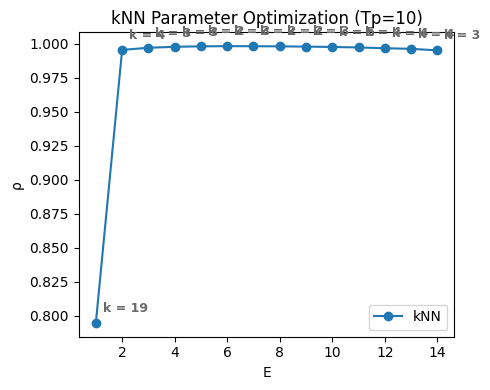

Best parameters:


,E,best_k,best_rho
0,6,3,0.99837


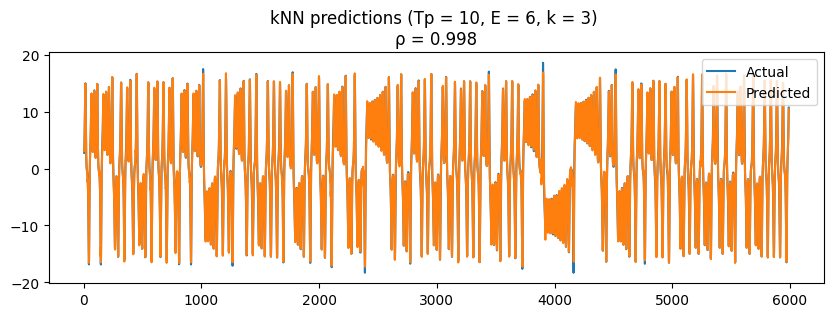

In [12]:
# Optimize kNN parameters
E_range = range(1, 15)
k_range = range(2, 20)
tau = -1
Tp = 10

knn_results, predictions = optimized_knn_E_vs_rho(df, 'x', E_range, tau, Tp, k_range, exclusion_radius=12)

# --- Plot parameter optimization ---
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(knn_results['E'], knn_results['best_rho'], marker='o', color='tab:blue', label='kNN')
for idx, row in knn_results.iterrows():
    ax.annotate(f'k = {int(row["best_k"])}',(row['E'], row['best_rho']), textcoords="offset points", 
        xytext=(5, 8), ha='left', fontsize=9, fontweight='bold',color='dimgray')
ax.set_xlabel('E')
ax.set_ylabel('ρ')
ax.set_title(f'kNN Parameter Optimization (Tp={Tp})')
ax.legend()
plt.tight_layout()
plt.show()

# Display best E/k pair
print('Best parameters:')
best = knn_results.sort_values(by='best_rho', ascending=False).head(1).reset_index(drop=True)
display(best)

best_E = best.loc[0,'E']
best_k = best.loc[0,'best_k']

knn_results, predictions = optimized_knn_E_vs_rho(df, 'x', [best_E], tau, Tp, [best_k], exclusion_radius=12)

# --- Plot observed vs. predicted values ---
fig, ax = plt.subplots(figsize=(10,3))
predictions.plot(y=['Actual', 'Predicted'], ax=ax)
ax.set_title(f'kNN predictions (Tp = {Tp}, E = {knn_results.loc[0,'E']}, k = {knn_results.loc[0,'best_k']}) \nρ = {knn_results.loc[0,'best_rho']:.3f}')
plt.show()

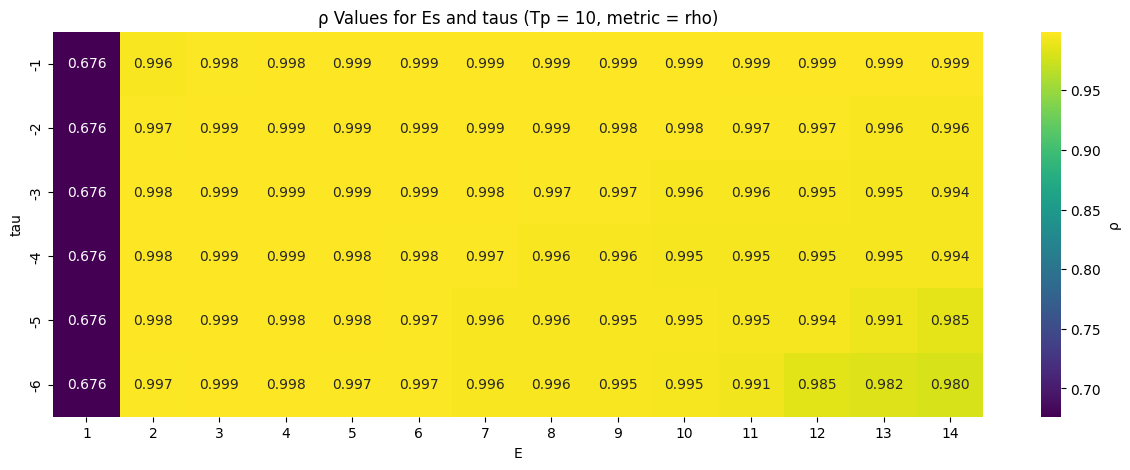

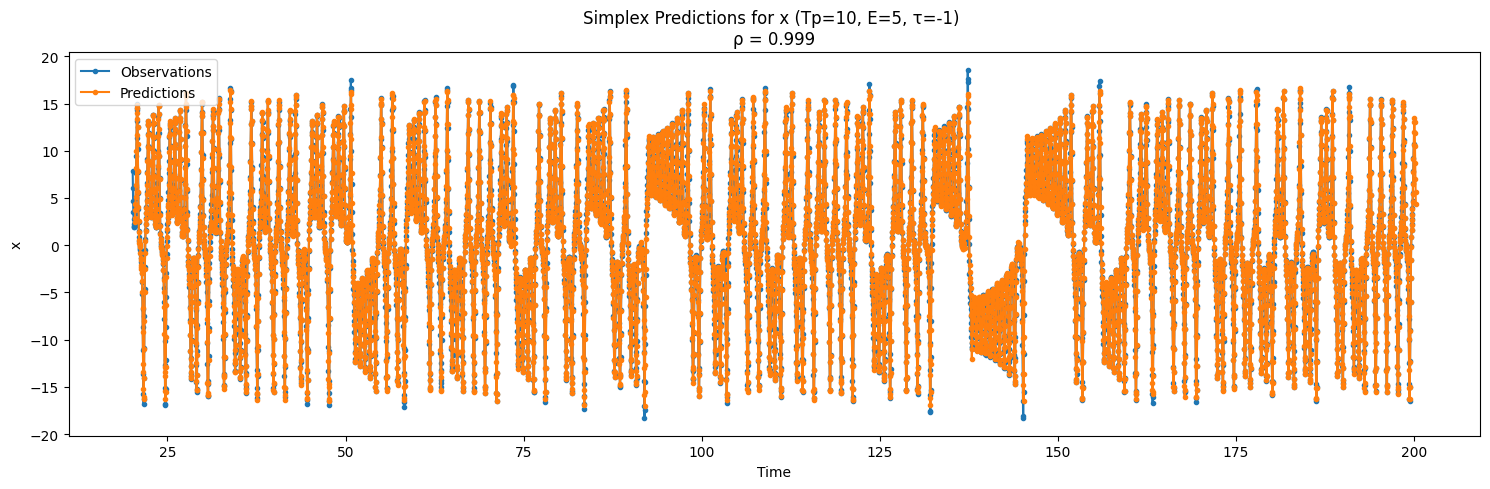

In [14]:
# Simplex
E = list(range(1,15))
tau = list(reversed(range(-6,0)))
Tp = 10
simplex = simplex_wrapper(dataFrame=df, columns='x', target='x', E=E, Tp=Tp, tau=tau, 
                          sig=0.1, metric='rho', figsize=(15,5), decimals=3)

# Choosing parameters based on E/tau grid search
E = 5
tau = -1
simplex = simplex_wrapper(dataFrame=df, columns='x', target='x', E=E, Tp=Tp, tau=tau, 
                          sig=0.05, metric='rho', figsize=(15,5), decimals=3, showPlot=True)

<>:53: SyntaxWarning: invalid escape sequence '\D'
<>:53: SyntaxWarning: invalid escape sequence '\D'
/var/folders/2l/rp17r8915p798zn96xv29vqm0000gp/T/ipykernel_70481/1719406134.py:53: SyntaxWarning: invalid escape sequence '\D'
  plt.colorbar(sc3, ax=ax3, shrink=0.5, label='$\Delta$ Error')


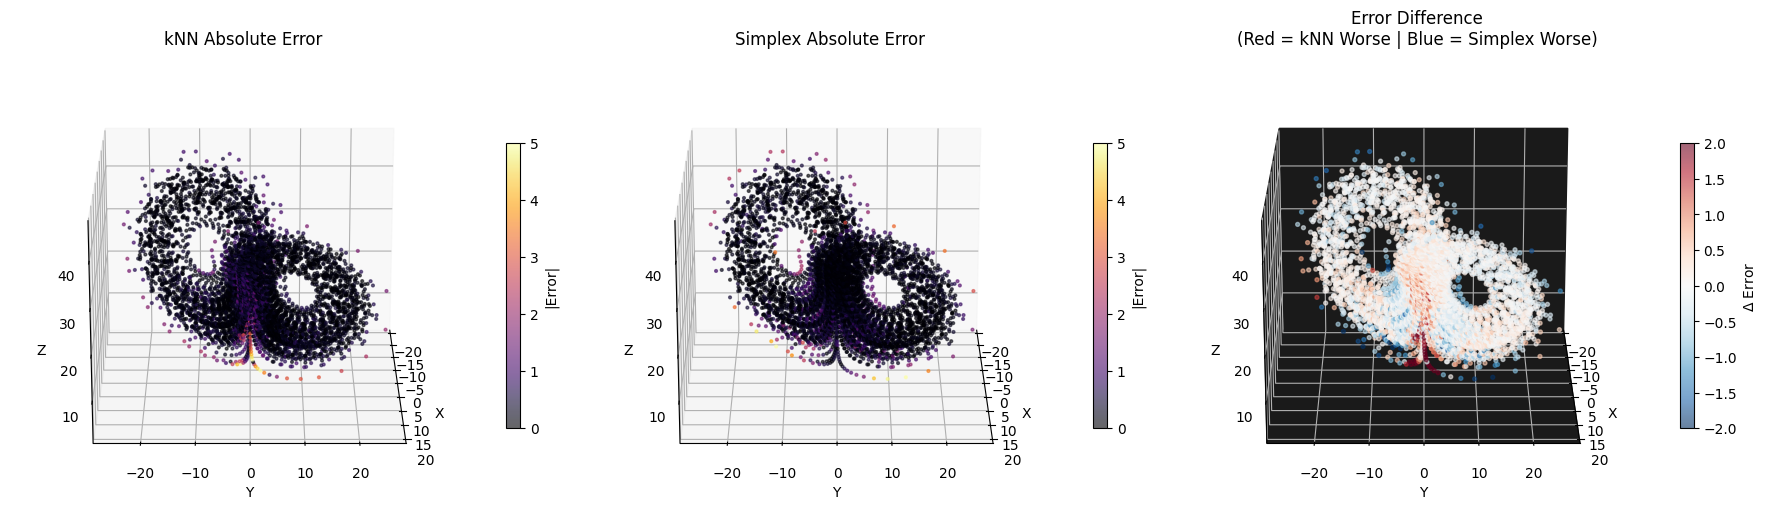

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

# 1. Calculate Absolute Errors
df_plot = df.copy()

# Add kNN errors
df_plot.loc[predictions.index, 'knn_err'] = np.abs(predictions['Actual'] - predictions['Predicted'])

# Add Simplex errors
# 1. Identify the common indices
common_indices = df_plot.index.intersection(simplex['Predictions'].index)

# 2. Calculate the error only for those common indices
# We use .loc[common_indices] on both sides to ensure perfect alignment
diff = simplex['Predictions'].loc[common_indices, 'Observations'] - \
       simplex['Predictions'].loc[common_indices, 'Predictions']

# 3. Assign the absolute error back to df_plot
df_plot.loc[common_indices, 'simplex_err'] = np.abs(diff)
# df_plot.loc[simplex['Predictions'].index, 'simplex_err'] = np.abs(simplex['Predictions']['Observations'] - simplex['Predictions']['Predictions'])

# Calculate the difference (Positive = kNN is worse, Negative = Simplex is worse)
df_plot['err_diff'] = df_plot['knn_err'] - df_plot['simplex_err']

df_plot = df_plot.dropna(subset=['knn_err', 'simplex_err'])

# 2. Plotting
fig = plt.figure(figsize=(18, 6))

# --- Subplot 1: kNN Error ---
ax1 = fig.add_subplot(131, projection='3d')
sc1 = ax1.scatter(df_plot['x'], df_plot['y'], df_plot['z'], c=df_plot['knn_err'], cmap='inferno', s=4, alpha=0.6, vmin=0, vmax=5)
ax1.set_title("kNN Absolute Error")
plt.colorbar(sc1, ax=ax1, shrink=0.5, label='|Error|')

# --- Subplot 2: Simplex Error ---
ax2 = fig.add_subplot(132, projection='3d')
sc2 = ax2.scatter(df_plot['x'], df_plot['y'], df_plot['z'], c=df_plot['simplex_err'], cmap='inferno', s=4, alpha=0.6, vmin=0, vmax=5)
ax2.set_title("Simplex Absolute Error")
plt.colorbar(sc2, ax=ax2, shrink=0.5, label='|Error|')

# --- Subplot 3: Comparison (kNN Error - Simplex Error) ---
ax3 = fig.add_subplot(133, projection='3d')
# Use a diverging colormap: Red = kNN fails more, Blue = Simplex fails more
sc3 = ax3.scatter(df_plot['x'], df_plot['y'], df_plot['z'], c=df_plot['err_diff'], cmap='RdBu_r', s=8, alpha=0.6,
                  vmin=-2, vmax=2)
ax3.xaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
ax3.yaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
ax3.zaxis.set_pane_color((0.1, 0.1, 0.1, 1.0))
ax3.set_title("Error Difference\n(Red = kNN Worse | Blue = Simplex Worse)")
plt.colorbar(sc3, ax=ax3, shrink=0.5, label='$\Delta$ Error')

for ax in [ax1, ax2, ax3]:
    ax.view_init(elev=20, azim=0)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

plt.tight_layout()
plt.show()